In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b9= bd.iloc[147]

In [4]:
b9['datetime']

'2020-10-10,16:23:39.619291+00:00'

In [5]:
lat= literal_eval(b9['lat_stereo_g16'])
long= literal_eval(b9['lon_stereo_g16'])
alt= literal_eval(b9['alt_stereo_g16'])
energy = literal_eval(b9['energyJoules_stereo_g16'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

53 53 53 53


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

33


In [9]:
totalmass= 0
totalh= 0 
for i in range (33): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.0006602904676045074 0.0003081355515487701 0.003081355515487701


In [11]:
totalh

41601.81714419438

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

2.3386009799999954
-0.15964575999998942
0.30493801000000076
0.3781008400000019
-2.8621743700000053
2.431543480000002
0.37011370999999826
-0.5825342899999981
0.47953561999999295
-0.043273919999990085
0.27327906999998675
-0.3951114099999984
-0.14526961999999344
2.7006137999999993
0.0023182399999939207
0.42111750000000825
-0.36798085000000924
0.13411303000000885
0.6129660299999955
0.030424820000007458
0.3232265899999902
0.18788881000000401
0.2894983000000053
0.47740415999999186
0.2616443499999974
-0.085570919999995
0.9494104799999974
0.42550930000000164
0.5603180300000048
0.3679347500000034
0.3735395799999992
0.14107124999999598
0.1929505300000045
0.1516508899999991
0.2718398499999921
0.2977387199999981
0.3222274000000027
0.577798290000004
-0.20746504000000243
0.2356907599999971
1.8088492899999977
0.0003067300000054729
0.0008247500000067021
0.0003109599999930879
-0.000529999999997699
-3.63099999987071e-05
-0.00027921000000219465
-3.2050000001504486e-05
0.0004742600000042785
0.001041599999

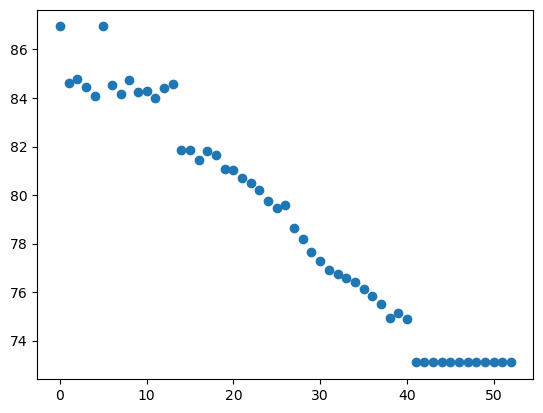

In [13]:
plt.scatter(range(len(alt)), alt)